# F1 Strategy Predictor — 2025 Data Pipeline
### Transformer-Based Tyre Degradation Modelling
This notebook:
1. Fetches 2025 race-only laps via FastF1
2. Cleans & feature-engineers the dataset
3. Trains a **Transformer encoder** to learn tyre deg from sequences
4. Exports `strategy_2025_race_only.csv` for the FastAPI backend

## 0. Install / Imports

In [1]:
# Install if running fresh
# !pip install fastf1 torch scikit-learn pandas numpy

In [2]:
import warnings
warnings.filterwarnings('ignore')

import math
import numpy as np
import pandas as pd
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

import fastf1

# ── Paths ──────────────────────────────────────────────────────────────────
BASE_DIR  = Path('..').resolve()
OUT_DIR   = BASE_DIR / 'data'
OUT_DIR.mkdir(parents=True, exist_ok=True)

CACHE_DIR = BASE_DIR / '.fastf1_cache'
CACHE_DIR.mkdir(parents=True, exist_ok=True)
fastf1.Cache.enable_cache(str(CACHE_DIR))

MODEL_PATH = OUT_DIR / 'tyre_transformer.pt'
CSV_PATH   = OUT_DIR / 'strategy_2025_race_only.csv'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cpu


## 1. Helper Functions

In [3]:
def estimate_fuel_load(
    lap_number: int,
    total_laps: int,
    start_fuel_kg: float = 100.0,
    burn_per_lap: float = 1.7,
) -> float:
    """Linear fuel burn model. Returns remaining fuel (kg) at start of lap."""
    return max(0.0, start_fuel_kg - (lap_number - 1) * burn_per_lap)


def safe_session_load(year: int, event_name: str):
    """Load a Race session, returning None on any failure."""
    try:
        sess = fastf1.get_session(year, event_name, 'R')
        sess.load(laps=True, telemetry=False, weather=True)
        return sess
    except Exception as exc:
        tag = '[RATE LIMIT]' if ('429' in str(exc) or 'RateLimitExceeded' in str(exc)) else '[WARN]'
        print(f'{tag} {event_name}: {exc}')
        return None


def lap_to_row(lap, event_name: str, total_laps: int, air_temp: float, track_temp: float) -> dict:
    """Convert a single FastF1 lap row to a flat dict with all required features."""
    lap_no     = int(lap['LapNumber'])
    tyre_life  = lap.get('TyreLife')
    compound   = str(lap.get('Compound') or 'UNKNOWN').upper()
    lap_time_s = float(lap['LapTime'].total_seconds())

    fuel_kg   = estimate_fuel_load(lap_no, total_laps)
    fuel_corr = -0.03 * fuel_kg          # lighter car → faster laps

    # ── Physics-derived proxies (kept as extra features, NOT as targets) ──
    tyre_life_safe = tyre_life if pd.notna(tyre_life) else 1.0
    thermal_deg    = tyre_life_safe * (track_temp / 35.0) if pd.notna(track_temp) else np.nan
    mech_wear      = tyre_life_safe * (1.0 + (lap_no / max(total_laps, 1)) * 0.15)

    return {
        'Season'          : 2025,
        'EventName'       : event_name,
        'Driver'          : lap.get('Driver'),
        'LapNumber'       : lap_no,
        'TotalLaps'       : total_laps,
        'TyreLife'        : tyre_life,
        'Compound'        : compound,
        'TrackStatus'     : lap.get('TrackStatus'),
        'LapTimeSeconds'  : lap_time_s,
        'FuelLoadKgEst'   : fuel_kg,
        'FuelCorrection'  : fuel_corr,
        'AirTemp'         : air_temp,
        'TrackTemp'       : track_temp,
        'ThermalDegProxy' : thermal_deg,
        'MechWearProxy'   : mech_wear,
        'LapFrac'         : lap_no / max(total_laps, 1),   # 0→1 race progress
    }

## 2. Fetch 2025 Race Data

In [5]:
schedule = fastf1.get_event_schedule(2025, include_testing=False)
schedule = schedule[schedule['Session5'].notna()].copy()
schedule['EventDate'] = pd.to_datetime(schedule['EventDate'], utc=True)
completed = schedule[schedule['EventDate'] <= pd.Timestamp.utcnow()]
print(f'Completed 2025 events: {len(completed)}')
completed[['EventName', 'EventDate']]

Completed 2025 events: 24


,EventName,EventDate
1,Australian Grand Prix,2025-03-16 00:00:00+00:00
2,Chinese Grand Prix,2025-03-23 00:00:00+00:00
3,Japanese Grand Prix,2025-04-06 00:00:00+00:00
4,Bahrain Grand Prix,2025-04-13 00:00:00+00:00
5,Saudi Arabian Grand Prix,2025-04-20 00:00:00+00:00
6,Miami Grand Prix,2025-05-04 00:00:00+00:00
7,Emilia Romagna Grand Prix,2025-05-18 00:00:00+00:00
8,Monaco Grand Prix,2025-05-25 00:00:00+00:00
9,Spanish Grand Prix,2025-06-01 00:00:00+00:00
10,Canadian Grand Prix,2025-06-15 00:00:00+00:00


In [6]:
all_rows = []

for _, event in completed.iterrows():
    event_name = event['EventName']
    sess = safe_session_load(2025, event_name)
    if sess is None:
        continue

    # ── Weather ────────────────────────────────────────────────────────────
    wx        = sess.weather_data if hasattr(sess, 'weather_data') else pd.DataFrame()
    air_temp  = float(wx['AirTemp'].mean())   if 'AirTemp'   in wx.columns else np.nan
    track_temp = float(wx['TrackTemp'].mean()) if 'TrackTemp' in wx.columns else np.nan

    # ── Laps ───────────────────────────────────────────────────────────────
    laps = sess.laps.copy()
    laps = laps[laps['LapTime'].notna()]          # drop laps with no time
    laps = laps[laps['PitOutTime'].isna()]         # drop out-laps
    laps = laps[laps['PitInTime'].isna()]          # drop in-laps

    if laps.empty:
        print(f'  [SKIP] No valid laps: {event_name}')
        continue

    total_laps = int(laps['LapNumber'].max())
    print(f'  [OK] {event_name}: {len(laps)} laps, {total_laps} total')

    for _, lap in laps.iterrows():
        try:
            all_rows.append(lap_to_row(lap, event_name, total_laps, air_temp, track_temp))
        except Exception as e:
            pass   # silently skip malformed laps

raw_df = pd.DataFrame(all_rows)
print(f'\nTotal rows collected: {len(raw_df)}')
raw_df.head()

core           INFO 	Loading data for Australian Grand Prix - Race [v3.5.3]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No

  [OK] Australian Grand Prix: 781 laps, 57 total


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 	Data has been written to cache!

  [OK] Chinese Grand Prix: 1013 laps, 56 total


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 	Data has been written to cache!

...

req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 	Data has been written to cache!

  [OK] Qatar Grand Prix: 982 laps, 57 total


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 	Data has been written to cache!

  [OK] Abu Dhabi Grand Prix: 1102 laps, 58 total

Total rows collected: 24794


,Season,EventName,Driver,LapNumber,TotalLaps,TyreLife,Compound,TrackStatus,LapTimeSeconds,FuelLoadKgEst,FuelCorrection,AirTemp,TrackTemp,ThermalDegProxy,MechWearProxy,LapFrac
0,2025,Australian Grand Prix,VER,1,57,1.0,INTERMEDIATE,124,119.392,100.0,-3.000,15.707865,18.942135,0.541204,1.002632,0.017544
1,2025,Australian Grand Prix,VER,6,57,6.0,INTERMEDIATE,4,139.654,91.5,-2.745,15.707865,18.942135,3.247223,6.094737,0.105263
2,2025,Australian Grand Prix,VER,7,57,7.0,INTERMEDIATE,41,136.447,89.8,-2.694,15.707865,18.942135,3.788427,7.128947,0.122807
3,2025,Australian Grand Prix,VER,8,57,8.0,INTERMEDIATE,1,96.830,88.1,-2.643,15.707865,18.942135,4.329631,8.168421,0.140351
4,2025,Australian Grand Prix,VER,9,57,9.0,INTERMEDIATE,1,94.315,86.4,-2.592,15.707865,18.942135,4.870835,9.213158,0.157895


## 3. Clean & Impute

In [7]:
df = raw_df.copy()

# ── 3.1  Remove obvious outliers (SC laps, VSC, red flags) ────────────────
# TrackStatus: '1'=clear, '2'=yellow, '4'=SC, '5'=red, '6'=VSC, '7'=VSC end
df = df[df['TrackStatus'].isin(['1', 1, np.nan, None]) | df['TrackStatus'].isna()]

# Lap time sanity: keep laps within ±15 % of the event median
event_medians = df.groupby('EventName')['LapTimeSeconds'].transform('median')
df = df[(df['LapTimeSeconds'] >= event_medians * 0.85) &
        (df['LapTimeSeconds'] <= event_medians * 1.15)]

# ── 3.2  Group-median imputation (driver × event) ─────────────────────────
group_key = ['EventName', 'Driver']

for col in ['TyreLife', 'AirTemp', 'TrackTemp', 'ThermalDegProxy', 'MechWearProxy']:
    df[col] = df.groupby(group_key)[col].transform(
        lambda s: s.fillna(s.median())
    )

# Final fallback: global median
for col in ['TyreLife', 'AirTemp', 'TrackTemp', 'ThermalDegProxy', 'MechWearProxy']:
    df[col] = df[col].fillna(df[col].median())

# ── 3.3  Encode compound ──────────────────────────────────────────────────
COMPOUND_ORDER = {'SOFT': 0, 'MEDIUM': 1, 'HARD': 2,
                  'INTERMEDIATE': 3, 'WET': 4, 'UNKNOWN': 5}
df['CompoundCode'] = df['Compound'].map(COMPOUND_ORDER).fillna(5).astype(int)

print(f'Clean rows: {len(df)}')
print(df[['EventName','Driver','LapNumber','Compound','TyreLife','LapTimeSeconds']].head(10))

Clean rows: 22677
                EventName Driver  LapNumber      Compound  TyreLife  \
3   Australian Grand Prix    VER          8  INTERMEDIATE       8.0   
4   Australian Grand Prix    VER          9  INTERMEDIATE       9.0   
5   Australian Grand Prix    VER         10  INTERMEDIATE      10.0   
6   Australian Grand Prix    VER         11  INTERMEDIATE      11.0   
7   Australian Grand Prix    VER         12  INTERMEDIATE      12.0   
8   Australian Grand Prix    VER         13  INTERMEDIATE      13.0   
9   Australian Grand Prix    VER         14  INTERMEDIATE      14.0   
10  Australian Grand Prix    VER         15  INTERMEDIATE      15.0   
11  Australian Grand Prix    VER         16  INTERMEDIATE      16.0   
12  Australian Grand Prix    VER         17  INTERMEDIATE      17.0   

    LapTimeSeconds  
3           96.830  
4           94.315  
5           92.650  
6           92.453  
7           91.591  
8           91.271  
9           90.639  
10          90.328  
11         

## 4. Build Tyre-Stint Sequences
The Transformer operates on **per-stint sequences**: each token is one lap on a given tyre. The model learns how lap time degrades as `TyreLife` grows — entirely from data, no hand-coded formula.

In [8]:
# ── 4.1  Assign stint IDs ─────────────────────────────────────────────────
df = df.sort_values(['EventName', 'Driver', 'LapNumber']).reset_index(drop=True)

df['StintID'] = (
    df.groupby(['EventName', 'Driver'])['Compound']
      .transform(lambda s: (s != s.shift()).cumsum())
)

# ── 4.2  Numerical feature columns ───────────────────────────────────────
FEAT_COLS = [
    'TyreLife',       # primary tyre age signal
    'LapFrac',        # race progress  (0→1)
    'FuelLoadKgEst',  # fuel weight
    'TrackTemp',      # surface temperature
    'AirTemp',
    'ThermalDegProxy',
    'MechWearProxy',
]
TARGET_COL = 'LapTimeSeconds'

# ── 4.3  Scale ────────────────────────────────────────────────────────────
scaler_X = StandardScaler()
scaler_y = StandardScaler()

df[FEAT_COLS]  = scaler_X.fit_transform(df[FEAT_COLS])
df['LapTimeZ'] = scaler_y.fit_transform(df[[TARGET_COL]])

print('Feature scaling done.')

# ── 4.4  Group into stint sequences ──────────────────────────────────────
SEQ_LEN = 30   # max laps per stint (pad/truncate to this)

sequences, targets, compounds = [], [], []

stint_groups = df.groupby(['EventName', 'Driver', 'StintID'])

for _, grp in stint_groups:
    grp = grp.sort_values('LapNumber')
    if len(grp) < 3:          # ignore stints shorter than 3 laps
        continue

    feats = grp[FEAT_COLS].values.astype(np.float32)
    tgts  = grp['LapTimeZ'].values.astype(np.float32)
    comp  = int(grp['CompoundCode'].iloc[0])

    # Pad or truncate
    L = len(feats)
    if L < SEQ_LEN:
        pad    = np.zeros((SEQ_LEN - L, len(FEAT_COLS)), dtype=np.float32)
        feats  = np.vstack([feats, pad])
        tpad   = np.zeros(SEQ_LEN - L, dtype=np.float32)
        tgts   = np.concatenate([tgts, tpad])
    else:
        feats = feats[:SEQ_LEN]
        tgts  = tgts[:SEQ_LEN]

    sequences.append(feats)
    targets.append(tgts)
    compounds.append(comp)

sequences = np.array(sequences)   # (N, SEQ_LEN, num_features)
targets   = np.array(targets)     # (N, SEQ_LEN)
compounds = np.array(compounds)   # (N,)

print(f'Stint sequences: {len(sequences)}  |  Shape: {sequences.shape}')

Feature scaling done.
Stint sequences: 974  |  Shape: (974, 30, 7)


## 5. PyTorch Dataset & DataLoader

In [9]:
class TyreDegDataset(Dataset):
    """Each sample = one tyre stint. X: (SEQ_LEN, features), y: (SEQ_LEN,) lap times."""

    def __init__(self, X, y, compounds):
        self.X         = torch.tensor(X, dtype=torch.float32)
        self.y         = torch.tensor(y, dtype=torch.float32)
        self.compounds = torch.tensor(compounds, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.compounds[idx], self.y[idx]


# Train / val / test split (70 / 15 / 15)
idx = np.arange(len(sequences))
tr_idx, tmp_idx = train_test_split(idx, test_size=0.30, random_state=42)
va_idx, te_idx  = train_test_split(tmp_idx, test_size=0.50, random_state=42)

def make_loader(indices, shuffle=True):
    ds = TyreDegDataset(sequences[indices], targets[indices], compounds[indices])
    return DataLoader(ds, batch_size=64, shuffle=shuffle, num_workers=0)

train_loader = make_loader(tr_idx, shuffle=True)
val_loader   = make_loader(va_idx, shuffle=False)
test_loader  = make_loader(te_idx, shuffle=False)

print(f'Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')

Train batches: 11 | Val: 3 | Test: 3


## 6. Transformer Architecture

```
Input (SEQ_LEN × num_feats)
    │
    ├─ Linear projection  →  d_model
    ├─ Compound embedding →  d_model  (added)
    ├─ Positional encoding (sinusoidal)
    │
    └─ TransformerEncoder (N layers, multi-head attention)
           │
       Linear head  →  1  (lap time per token)
```

- **Compound embedding** injects tyre type as a global context token (summed with input projection).
- **Causal masking** (optional): allows auto-regressive inference lap-by-lap.
- **Output**: predicted lap-time delta at every position in the stint.

In [10]:
class PositionalEncoding(nn.Module):
    """Standard sinusoidal positional encoding."""

    def __init__(self, d_model: int, max_len: int = 512, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)  # handles odd d_model too
        pe = pe.unsqueeze(0)                 # (1, max_len, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):                   # x: (B, T, d_model)
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)


class TyreDegTransformer(nn.Module):
    """
    Transformer encoder that maps a tyre stint sequence to per-lap lap times.

    Args:
        num_features   : number of numerical input features per lap
        num_compounds  : vocabulary size for compound embedding
        d_model        : internal model dimension
        nhead          : attention heads  (must divide d_model)
        num_layers     : encoder depth
        dim_feedforward: FFN hidden size
        dropout        : dropout rate
        use_causal_mask: if True, each lap can only attend to past laps
    """

    def __init__(
        self,
        num_features   : int,
        num_compounds  : int = 6,
        d_model        : int = 64,
        nhead          : int = 4,
        num_layers     : int = 3,
        dim_feedforward: int = 256,
        dropout        : float = 0.1,
        use_causal_mask: bool = True,
    ):
        super().__init__()
        self.d_model         = d_model
        self.use_causal_mask = use_causal_mask

        # Project raw features → d_model
        self.input_proj = nn.Linear(num_features, d_model)

        # Compound embedding — one vector per compound type, broadcast over seq
        self.compound_emb = nn.Embedding(num_compounds, d_model)

        self.pos_enc = PositionalEncoding(d_model, dropout=dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model        = d_model,
            nhead          = nhead,
            dim_feedforward= dim_feedforward,
            dropout        = dropout,
            batch_first    = True,   # (B, T, d_model)
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Regression head: d_model → 1 lap time per position
        self.head = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Linear(d_model // 2, 1),
        )

    def _causal_mask(self, seq_len: int, device):
        """Upper-triangular mask so position t cannot attend to t+1, t+2, …"""
        mask = torch.triu(
            torch.ones(seq_len, seq_len, device=device), diagonal=1
        ).bool()
        return mask   # True = ignore

    def forward(self, x, compound_ids):       # x: (B, T, F), compound_ids: (B,)
        B, T, _ = x.shape

        # Project features
        h = self.input_proj(x)                # (B, T, d_model)

        # Add compound context (broadcast across time)
        c = self.compound_emb(compound_ids)   # (B, d_model)
        h = h + c.unsqueeze(1)               # (B, T, d_model)

        # Positional encoding
        h = self.pos_enc(h)                   # (B, T, d_model)

        # Transformer encoder
        mask = self._causal_mask(T, x.device) if self.use_causal_mask else None
        h = self.encoder(h, mask=mask)        # (B, T, d_model)

        # Regression head
        out = self.head(h).squeeze(-1)        # (B, T)
        return out


NUM_FEATURES = len(FEAT_COLS)
model = TyreDegTransformer(
    num_features   = NUM_FEATURES,
    num_compounds  = 6,
    d_model        = 64,
    nhead          = 4,
    num_layers     = 3,
    dim_feedforward= 256,
    dropout        = 0.1,
    use_causal_mask= True,
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model parameters: {total_params:,}')
print(model)

Model parameters: 152,961
TyreDegTransformer(
  (input_proj): Linear(in_features=7, out_features=64, bias=True)
  (compound_emb): Embedding(6, 64)
  (pos_enc): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (head): Sequential(
    (0): Linear(in_features=64, out_features=32, b

## 7. Training

In [11]:
EPOCHS    = 60
LR        = 3e-4
PATIENCE  = 10      # early stopping

criterion = nn.HuberLoss(delta=1.0)   # robust to outlier laps
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

best_val_loss = float('inf')
no_improve    = 0
history       = {'train': [], 'val': []}


def run_epoch(loader, train=True):
    model.train(train)
    total_loss = 0.0
    with torch.set_grad_enabled(train):
        for X_batch, comp_batch, y_batch in loader:
            X_batch    = X_batch.to(DEVICE)
            comp_batch = comp_batch.to(DEVICE)
            y_batch    = y_batch.to(DEVICE)

            preds = model(X_batch, comp_batch)   # (B, SEQ_LEN)

            # Mask padded positions (where target == 0 AND TyreLife == 0)
            # We use y != 0 as a simple padding mask
            mask  = (y_batch != 0)
            loss  = criterion(preds[mask], y_batch[mask])

            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            total_loss += loss.item()

    return total_loss / len(loader)


print('Training Transformer …\n')
for epoch in range(1, EPOCHS + 1):
    tr_loss  = run_epoch(train_loader, train=True)
    val_loss = run_epoch(val_loader,   train=False)
    scheduler.step()

    history['train'].append(tr_loss)
    history['val'].append(val_loss)

    improved = val_loss < best_val_loss
    if improved:
        best_val_loss = val_loss
        torch.save(model.state_dict(), MODEL_PATH)
        no_improve = 0
    else:
        no_improve += 1

    mark = '✓' if improved else ' '
    if epoch % 5 == 0 or epoch == 1:
        print(f'[{mark}] Epoch {epoch:3d}/{EPOCHS} | Train: {tr_loss:.4f} | Val: {val_loss:.4f}')

    if no_improve >= PATIENCE:
        print(f'\nEarly stop at epoch {epoch} (no improvement for {PATIENCE} epochs).')
        break

print(f'\nBest val loss: {best_val_loss:.4f} — model saved to {MODEL_PATH}')

Training Transformer …

[✓] Epoch   1/60 | Train: 0.4465 | Val: 0.4268
[✓] Epoch   5/60 | Train: 0.2737 | Val: 0.2440
[✓] Epoch  10/60 | Train: 0.2154 | Val: 0.1956
[✓] Epoch  15/60 | Train: 0.1864 | Val: 0.1729
[ ] Epoch  20/60 | Train: 0.1747 | Val: 0.1543
[✓] Epoch  25/60 | Train: 0.1555 | Val: 0.1325
[ ] Epoch  30/60 | Train: 0.1520 | Val: 0.1407
[ ] Epoch  35/60 | Train: 0.1484 | Val: 0.1263
[✓] Epoch  40/60 | Train: 0.1328 | Val: 0.1089
[✓] Epoch  45/60 | Train: 0.1352 | Val: 0.1070
[✓] Epoch  50/60 | Train: 0.1311 | Val: 0.1058
[ ] Epoch  55/60 | Train: 0.1302 | Val: 0.1050
[ ] Epoch  60/60 | Train: 0.1281 | Val: 0.1047

Best val loss: 0.1047 — model saved to C:\Aryan\Projek\F1-race-strat-predictor\backend\data\tyre_transformer.pt


## 8. Evaluation

In [12]:
# Load best checkpoint
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()

all_preds, all_true = [], []

with torch.no_grad():
    for X_batch, comp_batch, y_batch in test_loader:
        preds  = model(X_batch.to(DEVICE), comp_batch.to(DEVICE)).cpu().numpy()
        ys     = y_batch.numpy()
        mask   = (ys != 0)
        all_preds.extend(preds[mask])
        all_true.extend(ys[mask])

# Un-scale from Z-score back to seconds
pred_s = scaler_y.inverse_transform(np.array(all_preds).reshape(-1, 1)).flatten()
true_s = scaler_y.inverse_transform(np.array(all_true).reshape(-1, 1)).flatten()

mae  = mean_absolute_error(true_s, pred_s)
rmse = np.sqrt(np.mean((true_s - pred_s) ** 2))

print(f'Test MAE  : {mae:.3f} s')
print(f'Test RMSE : {rmse:.3f} s')

Test MAE  : 3.591 s
Test RMSE : 4.768 s


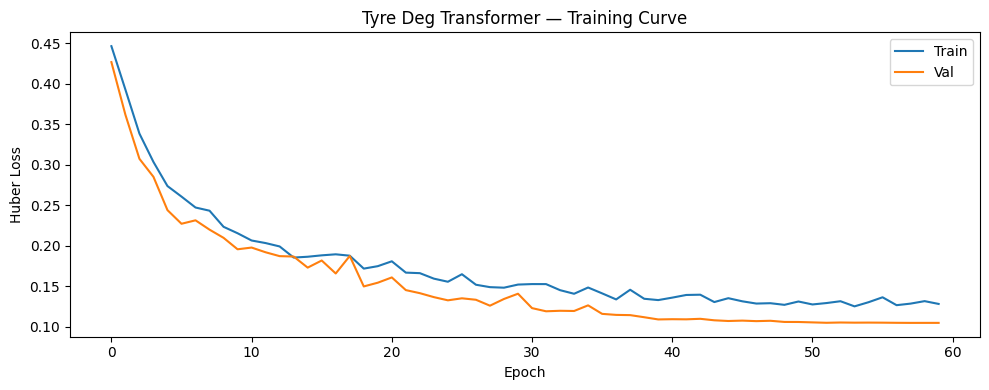

In [13]:
# Optional: loss curve (requires matplotlib)
try:
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, 4))
    plt.plot(history['train'], label='Train')
    plt.plot(history['val'],   label='Val')
    plt.xlabel('Epoch'); plt.ylabel('Huber Loss'); plt.legend()
    plt.title('Tyre Deg Transformer — Training Curve')
    plt.tight_layout(); plt.show()
except ImportError:
    print('Install matplotlib for loss curve.')

## 9. Attach Transformer Predictions to the Flat DataFrame
We run inference on the full cleaned dataset and store the predicted lap time alongside the raw label — this enriched CSV is what the FastAPI backend will use.

In [14]:
model.eval()

# Re-build a Dataset over ALL stints (no split)
full_ds     = TyreDegDataset(sequences, targets, compounds)
full_loader = DataLoader(full_ds, batch_size=128, shuffle=False)

all_seq_preds = []
with torch.no_grad():
    for X_b, c_b, _ in full_loader:
        p = model(X_b.to(DEVICE), c_b.to(DEVICE)).cpu().numpy()  # (B, SEQ_LEN)
        all_seq_preds.append(p)

all_seq_preds = np.vstack(all_seq_preds)   # (num_stints, SEQ_LEN)

# Flatten back to per-lap rows
pred_flat = []
for stint_preds in all_seq_preds:
    pred_flat.extend(stint_preds.tolist())

print(f'Total per-lap predictions generated: {len(pred_flat)}')

Total per-lap predictions generated: 29220


In [15]:
# ── Map predictions back to the per-stint order we built sequences from ──
# We need the same ordering used in Section 4 to align predictions correctly.

# Un-scale df for export (restore original feature values)
export_df = raw_df.copy()   # start from pre-scaled raw data

# Re-run stint assignment on raw_df to get matching stint groups
export_df = export_df.sort_values(['EventName', 'Driver', 'LapNumber']).reset_index(drop=True)
export_df['StintID'] = (
    export_df.groupby(['EventName', 'Driver'])['Compound']
              .transform(lambda s: (s != s.shift()).cumsum())
)

# Build stint-to-row index map (same filter as Section 4)
stint_row_indices = []
for name, grp in export_df.groupby(['EventName', 'Driver', 'StintID']):
    grp = grp.sort_values('LapNumber')
    if len(grp) < 3:
        continue
    L = min(len(grp), SEQ_LEN)
    stint_row_indices.append(grp.index[:L].tolist())

# Assign transformer predictions
export_df['TransformerLapTimeZ'] = np.nan

pred_cursor = 0
for i, row_idx_list in enumerate(stint_row_indices):
    L = len(row_idx_list)
    # all_seq_preds[i] has SEQ_LEN values; take first L
    export_df.loc[row_idx_list, 'TransformerLapTimeZ'] = all_seq_preds[i, :L]

# Un-scale transformer predictions back to seconds
valid_mask = export_df['TransformerLapTimeZ'].notna()
export_df.loc[valid_mask, 'TransformerLapTimePred'] = scaler_y.inverse_transform(
    export_df.loc[valid_mask, ['TransformerLapTimeZ']]
).flatten()

print('Predictions mapped. Non-null rows:', valid_mask.sum())
export_df[['EventName','Driver','LapNumber','Compound','LapTimeSeconds','TransformerLapTimePred']].head(10)

IndexError: index 974 is out of bounds for axis 0 with size 974

## 10. Export Final CSV

In [16]:
EXPORT_COLS = [
    'Season', 'EventName', 'Driver',
    'LapNumber', 'TotalLaps', 'TyreLife', 'Compound', 'CompoundCode',
    'TrackStatus', 'StintID',
    'LapTimeSeconds',          # ground truth
    'TransformerLapTimePred',  # model prediction
    'FuelLoadKgEst', 'FuelCorrection',
    'AirTemp', 'TrackTemp',
    'ThermalDegProxy', 'MechWearProxy',
    'LapFrac',
]

# Only keep cols that actually exist (guard against missing columns)
EXPORT_COLS = [c for c in EXPORT_COLS if c in export_df.columns]

final_df = export_df[EXPORT_COLS].copy()
final_df = final_df[final_df['LapTimeSeconds'].notna()].reset_index(drop=True)

final_df.to_csv(CSV_PATH, index=False)
print(f'Exported {len(final_df):,} rows → {CSV_PATH}')
final_df.describe()

Exported 24,794 rows → C:\Aryan\Projek\F1-race-strat-predictor\backend\data\strategy_2025_race_only.csv


,Season,LapNumber,TotalLaps,TyreLife,StintID,LapTimeSeconds,FuelLoadKgEst,FuelCorrection,AirTemp,TrackTemp,ThermalDegProxy,MechWearProxy,LapFrac
count,24794.0,24794.000000,24794.000000,24356.000000,24794.000000,24794.000000,24794.000000,24794.000000,24794.000000,24794.000000,24794.000000,24794.000000,24794.000000
mean,2025.0,30.885214,61.287529,15.278946,1.657538,89.811149,49.798947,-1.493968,23.632352,35.566026,15.384520,16.384399,0.505551
std,0.0,18.248429,8.610534,10.073377,0.658266,12.655641,29.900098,0.897003,4.646705,9.670865,11.891133,11.406076,0.288586
min,2025.0,1.000000,44.000000,1.000000,1.000000,67.924000,0.000000,-3.000000,14.430000,18.942135,0.541204,1.001923,0.012821
25%,2025.0,15.000000,56.000000,7.000000,1.000000,80.642500,25.200000,-2.286000,20.077358,27.963522,6.447347,7.398276,0.253968
50%,2025.0,30.000000,58.000000,13.000000,2.000000,89.258000,50.700000,-1.521000,24.036527,33.852174,12.642804,14.350000,0.500000
75%,2025.0,45.000000,70.000000,21.000000,2.000000,97.758000,76.200000,-0.756000,27.052532,43.317500,21.039929,23.100000,0.757143
max,2025.0,78.000000,78.000000,71.000000,4.000000,152.918000,100.000000,-0.000000,30.347826,50.588272,87.872643,80.830769,1.000000


## 11. Inference Helper (for FastAPI)
The backend calls `predict_stint()` with a list of per-lap feature dicts and gets back predicted lap times.

In [17]:
import joblib

# Save scalers so the FastAPI backend can reload them
joblib.dump(scaler_X, OUT_DIR / 'scaler_X.pkl')
joblib.dump(scaler_y, OUT_DIR / 'scaler_y.pkl')
print('Scalers saved.')


def predict_stint(
    lap_features: list[dict],
    compound: str,
    model: TyreDegTransformer,
    scaler_X: StandardScaler,
    scaler_y: StandardScaler,
    seq_len: int = SEQ_LEN,
    device=DEVICE,
) -> np.ndarray:
    """
    Predict lap times for a single stint.

    Parameters
    ----------
    lap_features : list of dicts, each containing keys matching FEAT_COLS
    compound     : tyre compound string e.g. 'SOFT'

    Returns
    -------
    np.ndarray of shape (len(lap_features),) — predicted lap times in seconds
    """
    comp_code = COMPOUND_ORDER.get(compound.upper(), 5)
    L         = len(lap_features)

    feats = np.array([[row.get(c, 0.0) for c in FEAT_COLS] for row in lap_features],
                     dtype=np.float32)
    feats_scaled = scaler_X.transform(feats)    # (L, F)

    # Pad to seq_len
    if L < seq_len:
        pad          = np.zeros((seq_len - L, len(FEAT_COLS)), dtype=np.float32)
        feats_scaled = np.vstack([feats_scaled, pad])
    else:
        feats_scaled = feats_scaled[:seq_len]

    X_t = torch.tensor(feats_scaled, dtype=torch.float32).unsqueeze(0).to(device)  # (1, T, F)
    c_t = torch.tensor([comp_code], dtype=torch.long).to(device)

    model.eval()
    with torch.no_grad():
        pred_z = model(X_t, c_t).squeeze(0).cpu().numpy()  # (T,)

    pred_z  = pred_z[:L]    # trim padding
    pred_s  = scaler_y.inverse_transform(pred_z.reshape(-1, 1)).flatten()
    return pred_s


# ── Quick smoke test ────────────────────────────────────────────────────────
test_laps = [
    {'TyreLife': i, 'LapFrac': i/50, 'FuelLoadKgEst': 100 - i*1.7,
     'TrackTemp': 38.0, 'AirTemp': 28.0,
     'ThermalDegProxy': i*(38/35), 'MechWearProxy': i*(1 + i/50*0.15)}
    for i in range(1, 21)
]

preds = predict_stint(test_laps, 'SOFT', model, scaler_X, scaler_y)
print('Smoke test predictions (s):', np.round(preds, 2))

Scalers saved.
Smoke test predictions (s): [95.5  95.95 95.71 94.67 93.23 92.25 92.51 94.17 95.77 96.26 95.97 95.51
 95.56 96.06 96.64 96.81 96.5  95.9  95.55 96.13]
